In [2]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
from typing import List, Dict, Tuple
import matplotlib.pyplot as plt
import mplhep as hep
hep.style.use("CMS")

In [3]:
%config InlineBackend.figure_format = 'retina'

In [4]:
def parse_llr_file(file_path: Path) -> List[Dict]:
    results = []
    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            # Skip empty lines and headers
            if not line or line.startswith('Summary'):
                continue
            # Look for lines with the pattern: llr_name : μ = value
            match = re.match(r'^(.+?)\s*:\s*μ\s*=\s*([\d.]+)', line)
            if match:
                llr_name = match.group(1).strip()
                mu_value = float(match.group(2))
                results.append({'llr_name': llr_name, 'mu_value': mu_value})
    return results

def categorize_llr_type(llr_name: str) -> Tuple[str, int]:
    vs_count = llr_name.count('_vs_')   # Count _vs_ occurrences (for 2D/3D variables)
    x_count = llr_name.count('_x_')     # Count _x_ occurrences (for multivariate combinations)
    if vs_count > 0:
        if vs_count == 1: return 'from_2D', 2
        elif vs_count == 2: return 'from_3D', 3
        else: return f'from_{vs_count + 1}D', vs_count + 1
    elif x_count > 0:
        n_vars = x_count + 1  # n _x_ means n+1 variables
        return 'from_multivar', n_vars
    else:
        return 'from_1D', 1

def parse_multiple_llr_files(file_paths: List[Path]) -> pd.DataFrame:
    all_results = []
    for file_path in file_paths:
        print(f"Parsing {file_path}...")
        file_results = parse_llr_file(file_path)
        all_results.extend(file_results)
        print(f"  Found {len(file_results)} LLRs")
    
    # Create DataFrame
    df = pd.DataFrame(all_results)
    # Add categorization columns
    categories_and_nvars = df['llr_name'].apply(categorize_llr_type)
    df['llr_type'] = [cat for cat, nvars in categories_and_nvars]
    df['n_variables'] = [nvars for cat, nvars in categories_and_nvars]
    
    # Sort by mu_value (best limits first)
    df = df.sort_values('mu_value').reset_index(drop=True)
    
    print(f"\nTotal LLRs parsed: {len(df)}")
    print(f"LLR type distribution:")
    print(df['llr_type'].value_counts())
    
    return df

def remove_multivar_llrs(input_file: Path, output_file: Path):
    """Remove all multivariate LLRs (containing '_x_') from the file."""
    kept_lines = []
    removed_count = 0
    kept_count = 0
    
    with open(input_file, 'r') as f:
        for line in f:
            line_stripped = line.strip()
            
            # Keep header lines and empty lines
            if not line_stripped or line_stripped.startswith('Summary'):
                kept_lines.append(line)
                continue
            
            # Check if this is an LLR result line
            match = re.match(r'^(.+?)\s*:\s*μ\s*=\s*([\d.]+|None)', line_stripped)
            if match:
                llr_name = match.group(1).strip()
                
                # Remove if it contains '_x_' (multivariate)
                if '_x_' in llr_name:
                    removed_count += 1
                    print(f"REMOVE: {llr_name}")
                else:
                    kept_lines.append(line)
                    kept_count += 1
                    print(f"KEEP: {llr_name}")
            else:
                # Keep any other lines
                kept_lines.append(line)
    
    # Write filtered content to output file
    with open(output_file, 'w') as f:
        f.writelines(kept_lines)
    
    print(f"\nFiltering complete!")
    print(f"Kept: {kept_count} LLRs")
    print(f"Removed: {removed_count} LLRs")
    print(f"Output saved to: {output_file}")

def create_summary_table(df: pd.DataFrame):
    """Create a summary table of results."""
    print("\n" + "="*60)
    print("LLR PERFORMANCE SUMMARY")
    print("="*60)
    
    # Overall summary
    print(f"Total LLRs analyzed: {len(df)}")
    print(f"Best overall μ: {df['mu_value'].min():.3f}")
    print(f"Worst overall μ: {df['mu_value'].max():.3f}")
    
    # Summary by type
    print(f"\nSummary by LLR type:")
    print("-" * 40)
    summary = df.groupby('llr_type').agg({
        'mu_value': ['count', 'min', 'mean', 'std'],
        'llr_name': lambda x: x.iloc[0]  # Best LLR name
    }).round(3)
    
    for llr_type in summary.index:
        count = summary.loc[llr_type, ('mu_value', 'count')]
        min_mu = summary.loc[llr_type, ('mu_value', 'min')]
        mean_mu = summary.loc[llr_type, ('mu_value', 'mean')]
        
        # Find best LLR name safely - avoid floating point precision issues
        type_subset = df[df['llr_type'] == llr_type]
        if len(type_subset) > 0:
            best_idx = type_subset['mu_value'].idxmin()
            best_name = type_subset.loc[best_idx, 'llr_name']
        else:
            best_name = "No LLRs found"
        
        print(f"{llr_type}:")
        print(f"  Count: {count}")
        print(f"  Best μ: {min_mu:.3f}")
        print(f"  Mean μ: {mean_mu:.3f}")
        print(f"  Best LLR: {best_name}")
        print()
    
    # Multivar summary
    multivar_df = df[df['llr_type'] == 'from_multivar']
    if not multivar_df.empty:
        print("Multivariate LLR summary by variable count:")
        print("-" * 45)
        for n_vars in sorted(multivar_df['n_variables'].unique()):
            subset = multivar_df[multivar_df['n_variables'] == n_vars]
            if len(subset) > 0:
                best = subset.loc[subset['mu_value'].idxmin()]
                print(f"{n_vars} variables: {len(subset)} LLRs, best μ = {best['mu_value']:.3f}")
                print(f"  Best: {best['llr_name']}")
            else:
                print(f"{n_vars} variables: 0 LLRs")
    else:
        print("No multivariate LLRs found in dataset.")

In [5]:
projectdir = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New')
workdirs = [
    'LLR_odd',
    'LLR_odd_combos2to5',
    'LLR_odd_combos6',
    'LLR_odd_combos7to12',
]
file_paths = [projectdir / wd / 'fits_new' / 'summary_results.txt' for wd in workdirs]
df = parse_multiple_llr_files(file_paths)

# Save to CSV for further analysis
# output_file = "combined_llr_results.csv"
# df.to_csv(output_file, index=False)
# print(f"\nResults saved to {output_file}")

Parsing /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_odd/fits_new/summary_results.txt...
  Found 87 LLRs
Parsing /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_odd_combos2to5/fits_new/summary_results.txt...
  Found 1573 LLRs
Parsing /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_odd_combos6/fits_new/summary_results.txt...
  Found 924 LLRs
Parsing /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_odd_combos7to12/fits_new/summary_results.txt...
  Found 1586 LLRs

Total LLRs parsed: 4170
LLR type distribution:
from_multivar    4083
from_1D            66
from_2D            17
from_3D             4
Name: llr_type, dtype: int64


/cvmfs/sft.cern.ch/lcg/views/LCG_105/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/matplotlib/cbook.py:1072: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  x = np.asanyarray(x)


Scatter plot saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/llr_scatterplot_by_type.pdf


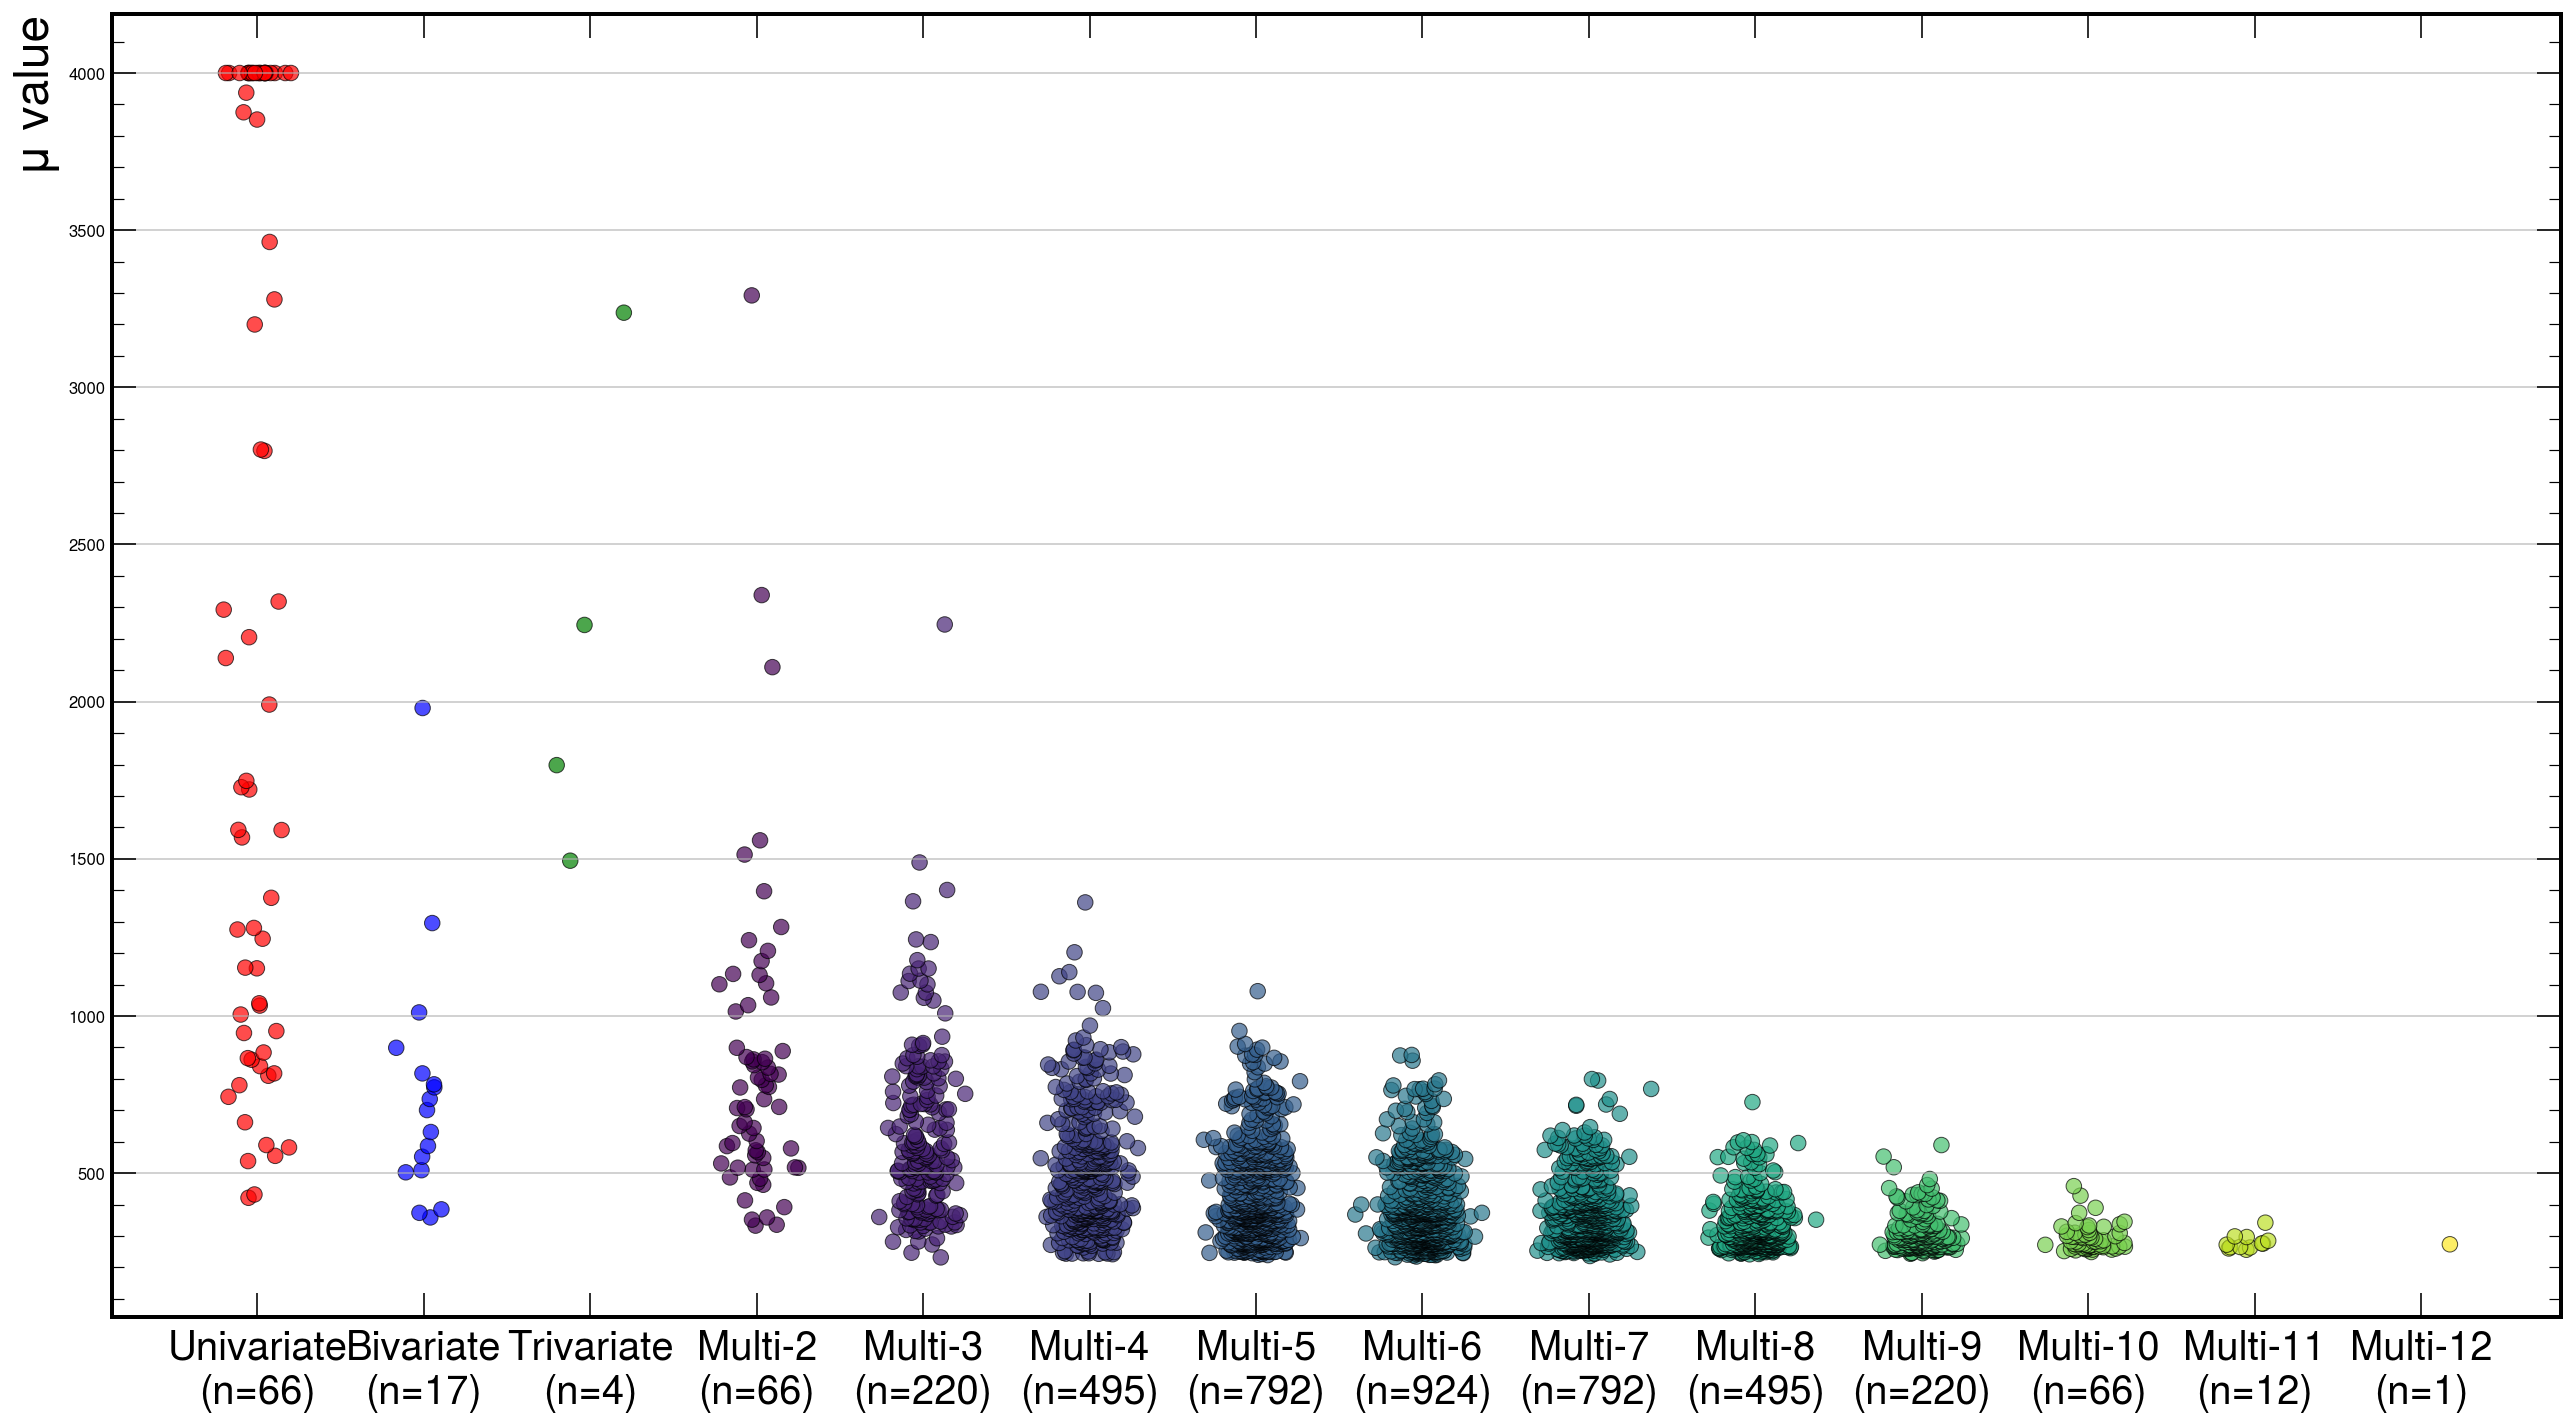

In [6]:
def create_scatter_plot_by_type(df: pd.DataFrame, output_dir):
    """Create scatter plots showing μ value distributions by LLR type."""
    hep.style.use("CMS")
    
    label_fontsize = 24
    tick_fontsize = 20
    
    fig, ax = plt.subplots(figsize=(18, 10))
    
    x_positions = []
    y_values = []
    colors = []
    labels = []
    
    current_x = 1
    
    # Add non-multivariate types
    type_mapping = {
        'from_1D': ('Univariate', 'red'),
        'from_2D': ('Bivariate', 'blue'), 
        'from_3D': ('Trivariate', 'green')
    }
    
    for llr_type, (label, color) in type_mapping.items():
        subset = df[df['llr_type'] == llr_type]
        if not subset.empty:
            # Add jitter to x-positions to avoid overlap
            x_jitter = np.random.normal(current_x, 0.1, len(subset))
            x_positions.extend(x_jitter)
            y_values.extend(subset['mu_value'])
            colors.extend([color] * len(subset))
            labels.append(f'{label}\n(n={len(subset)})')
            current_x += 1
    
    # Add multivariate with more descriptive names
    multivar_df = df[df['llr_type'] == 'from_multivar']
    if not multivar_df.empty:
        n_var_values = sorted(multivar_df['n_variables'].unique())
        viridis_colors = plt.cm.viridis(np.linspace(0, 1, len(n_var_values)))
        
        # More descriptive names for multivariate combinations
        multivar_names = {
            2: 'Multi-2', 3: 'Multi-3', 4: 'Multi-4', 5: 'Multi-5',
            6: 'Multi-6', 7: 'Multi-7', 8: 'Multi-8', 9: 'Multi-9',
            10: 'Multi-10', 11: 'Multi-11', 12: 'Multi-12'
        }
        
        for i, n_vars in enumerate(n_var_values):
            subset = multivar_df[multivar_df['n_variables'] == n_vars]
            # Add jitter to x-positions
            x_jitter = np.random.normal(current_x, 0.1, len(subset))
            x_positions.extend(x_jitter)
            y_values.extend(subset['mu_value'])
            colors.extend([viridis_colors[i]] * len(subset))
            labels.append(f'{multivar_names.get(n_vars, f"Multi-{n_vars}")}\n(n={len(subset)})')
            current_x += 1
    
    # Create scatter plot
    ax.scatter(x_positions, y_values, c=colors, s=60, alpha=0.7, 
               edgecolors='black', linewidth=0.5)
    
    # Set up axes exactly like the box plot
    ax.tick_params(axis='x', which='minor', bottom=False, top=False)
    ax.tick_params(axis='y', which='minor', left=True, right=True)
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, fontsize=tick_fontsize)
    
    # Clean styling - same as box plot
    ax.set_ylabel('μ value', fontsize=label_fontsize)
    ax.grid(True, alpha=0.7, axis='y', linestyle='-', linewidth=0.8)
    ax.grid(False, axis='x')
    
    plt.tight_layout()
    
    save_path = output_dir / "llr_scatterplot_by_type.pdf"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Scatter plot saved to {save_path}")
    
    plt.show()

# Usage
create_scatter_plot_by_type(df, projectdir)

Descriptive box plot saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/llr_boxplot_by_type.pdf


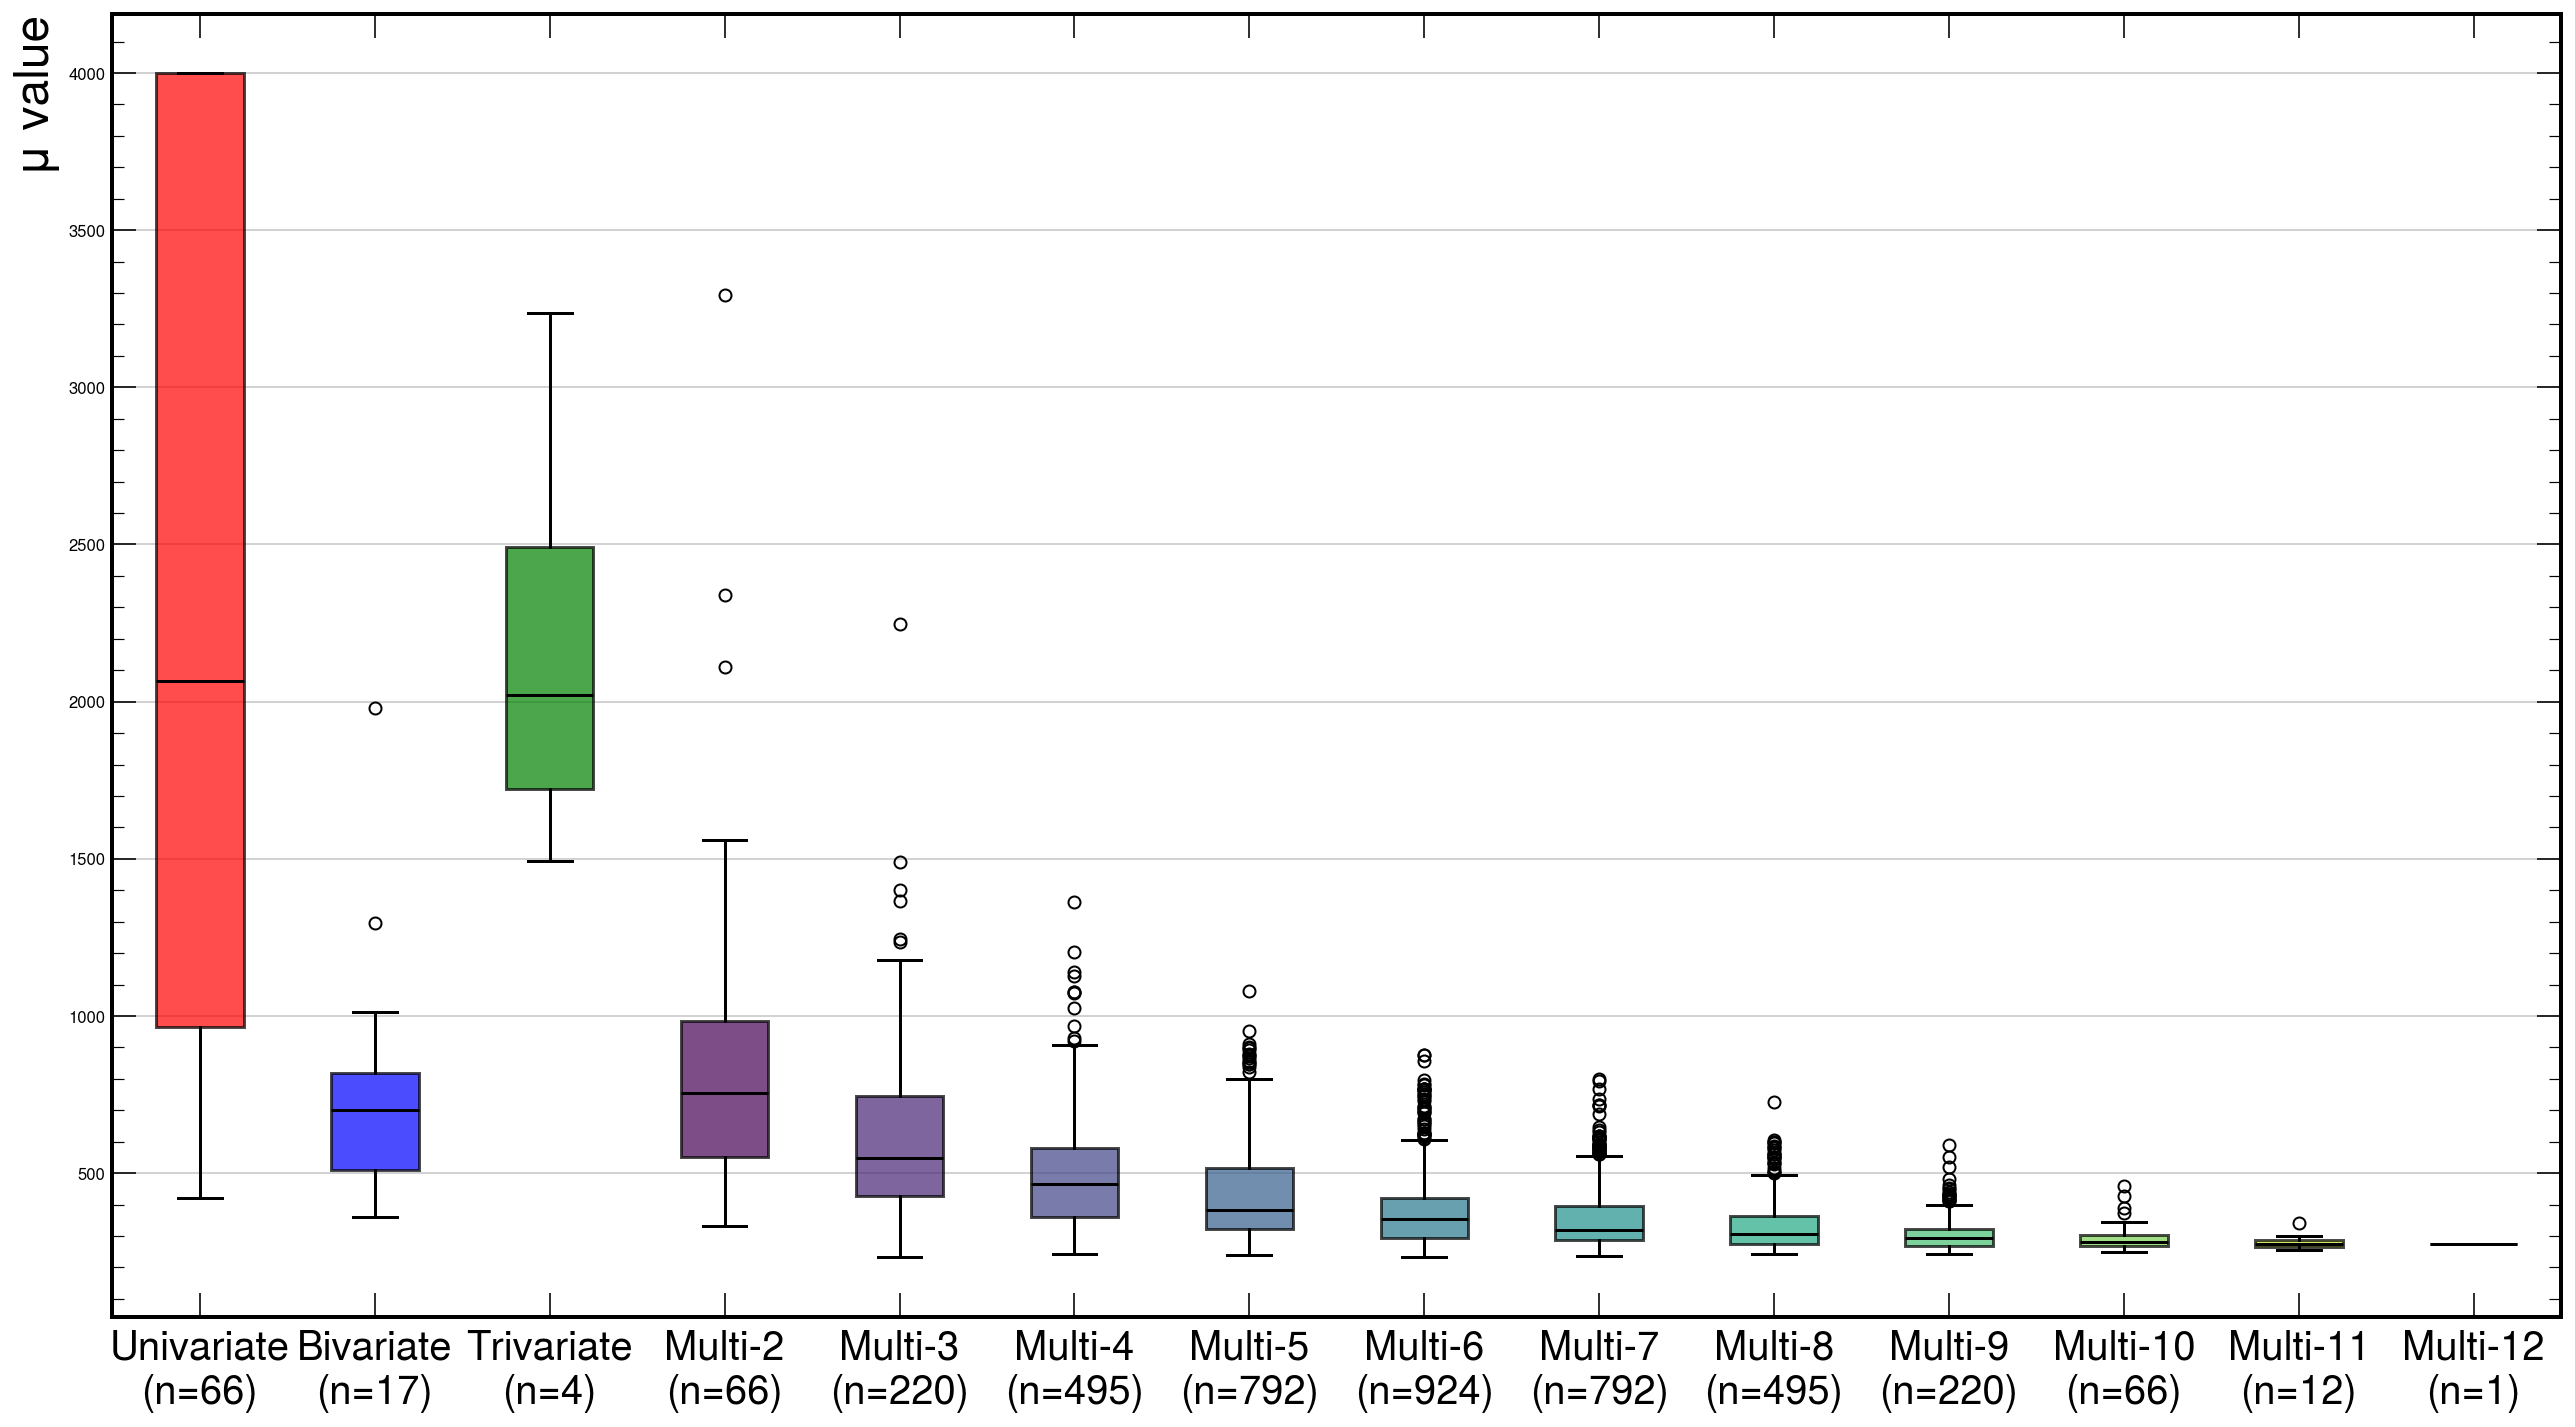

In [7]:
def create_box_plot_by_type(df: pd.DataFrame, output_dir):
    """Create box plots with more descriptive names for multivariate combinations."""
    
    label_fontsize = 24
    tick_fontsize = 20
    
    fig, ax = plt.subplots(figsize=(18, 10))
    
    plot_data = []
    labels = []
    colors = []
    
    # Add non-multivariate types
    type_mapping = {
        'from_1D': ('Univariate', 'red'),
        'from_2D': ('Bivariate', 'blue'), 
        'from_3D': ('Trivariate', 'green')
    }
    
    for llr_type, (label, color) in type_mapping.items():
        subset = df[df['llr_type'] == llr_type]
        if not subset.empty:
            plot_data.append(subset['mu_value'])
            labels.append(f'{label}\n(n={len(subset)})')
            colors.append(color)
    
    # Add multivariate with more descriptive names
    multivar_df = df[df['llr_type'] == 'from_multivar']
    if not multivar_df.empty:
        n_var_values = sorted(multivar_df['n_variables'].unique())
        viridis_colors = plt.cm.viridis(np.linspace(0, 1, len(n_var_values)))
        
        # More descriptive names for multivariate combinations
        multivar_names = {
            2: 'Multi-2', 3: 'Multi-3', 4: 'Multi-4', 5: 'Multi-5',
            6: 'Multi-6', 7: 'Multi-7', 8: 'Multi-8', 9: 'Multi-9',
            10: 'Multi-10', 11: 'Multi-11', 12: 'Multi-12'
        }
        
        for i, n_vars in enumerate(n_var_values):
            subset = multivar_df[multivar_df['n_variables'] == n_vars]
            plot_data.append(subset['mu_value'])
            labels.append(f'{multivar_names.get(n_vars, f"Multi-{n_vars}")}\n(n={len(subset)})')
            colors.append(viridis_colors[i])
    
    # Create box plot with improved styling
    bp = ax.boxplot(plot_data, labels=labels, patch_artist=True)
    
    # Color and style the boxes
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
        patch.set_linewidth(1.5)
    
    # Style whiskers, caps, and medians
    for element in ['whiskers', 'caps', 'medians']:
        for item in bp[element]:
            item.set_linewidth(1.5)
            item.set_color('black')
    
    # Remove minor ticks and clean up axes
    ax.tick_params(axis='x', which='minor', bottom=False, top=False)
    ax.tick_params(axis='y', which='minor', left=True, right=True)
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, fontsize=tick_fontsize)
    
    # Clean styling
    ax.set_ylabel('μ value', fontsize=label_fontsize)
    # ax.tick_params(axis='y', labelsize=tick_fontsize)
    # ax.minorticks_on()
    # ax.tick_params(axis='y', which='minor', left=True)
    ax.grid(True, alpha=0.7, axis='y', linestyle='-', linewidth=0.8)
    ax.grid(False, axis='x')
    # ax.spines['top'].set_visible(False)
    # ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    
    save_path = output_dir / "llr_boxplot_by_type.pdf"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Descriptive box plot saved to {save_path}")
    
    plt.show()

create_box_plot_by_type(df, projectdir)

Saved /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/llr_multivar_trend.pdf


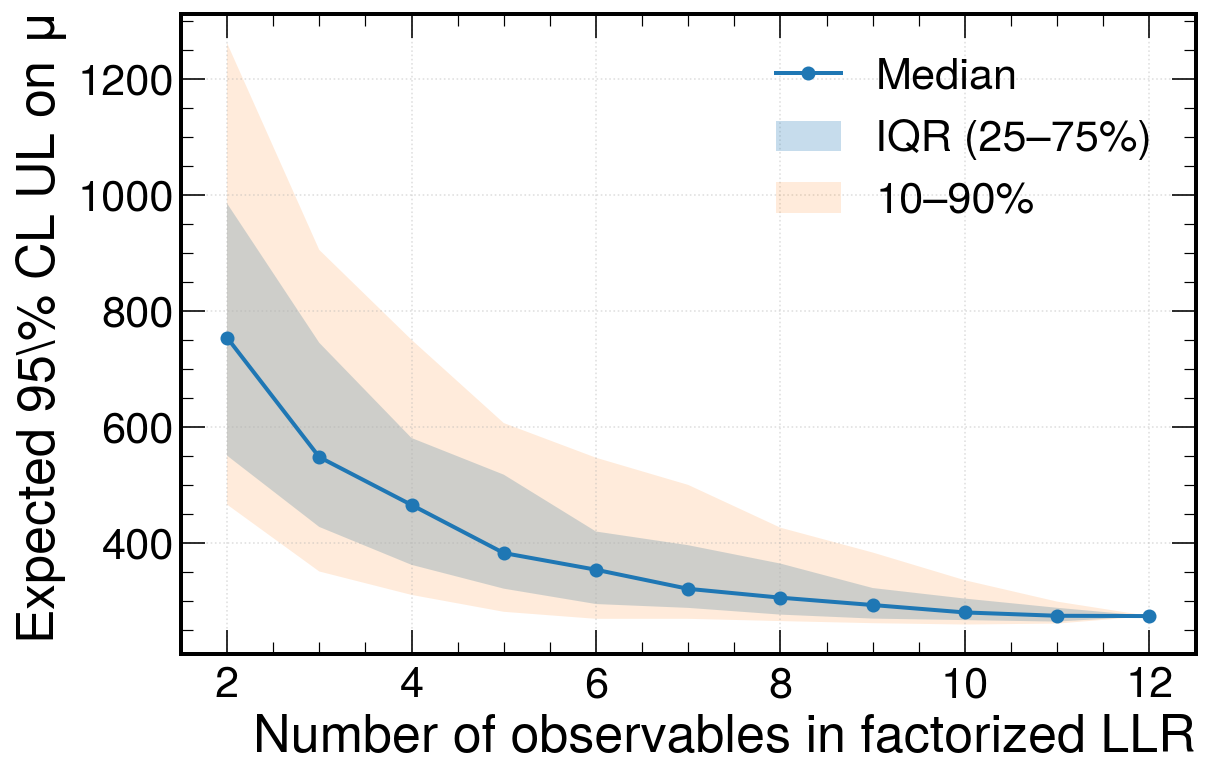

In [8]:
def plot_multivar_trend(df: pd.DataFrame, output_dir: Path):
    hep.style.use("CMS")

    mdf = df[df["llr_type"] == "from_multivar"].copy()
    if "n_variables" not in mdf.columns:
        raise ValueError("from_multivar rows must include n_variables")

    g = mdf.groupby("n_variables")["mu_value"]
    order = sorted(g.groups.keys())
    med = g.median().reindex(order)
    q25 = g.quantile(0.25).reindex(order)
    q75 = g.quantile(0.75).reindex(order)
    q10 = g.quantile(0.10).reindex(order)
    q90 = g.quantile(0.90).reindex(order)

    fig, ax = plt.subplots(figsize=(9,6))
    ax.plot(order, med.values, marker="o", lw=2, label="Median")

    ax.fill_between(order, q25.values, q75.values, alpha=0.25, label="IQR (25–75%)")
    ax.fill_between(order, q10.values, q90.values, alpha=0.15, label="10–90%")

    ax.set_xlabel("Number of observables in factorized LLR")
    ax.set_ylabel(r"Expected 95\% CL UL on $\mu$")
    ax.grid(True, alpha=0.4)
    ax.legend(frameon=False)

    out = output_dir / "llr_multivar_trend.pdf"
    fig.tight_layout(); fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"Saved {out}")

plot_multivar_trend(df, projectdir)

Saved /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/llr_global_scatter.pdf


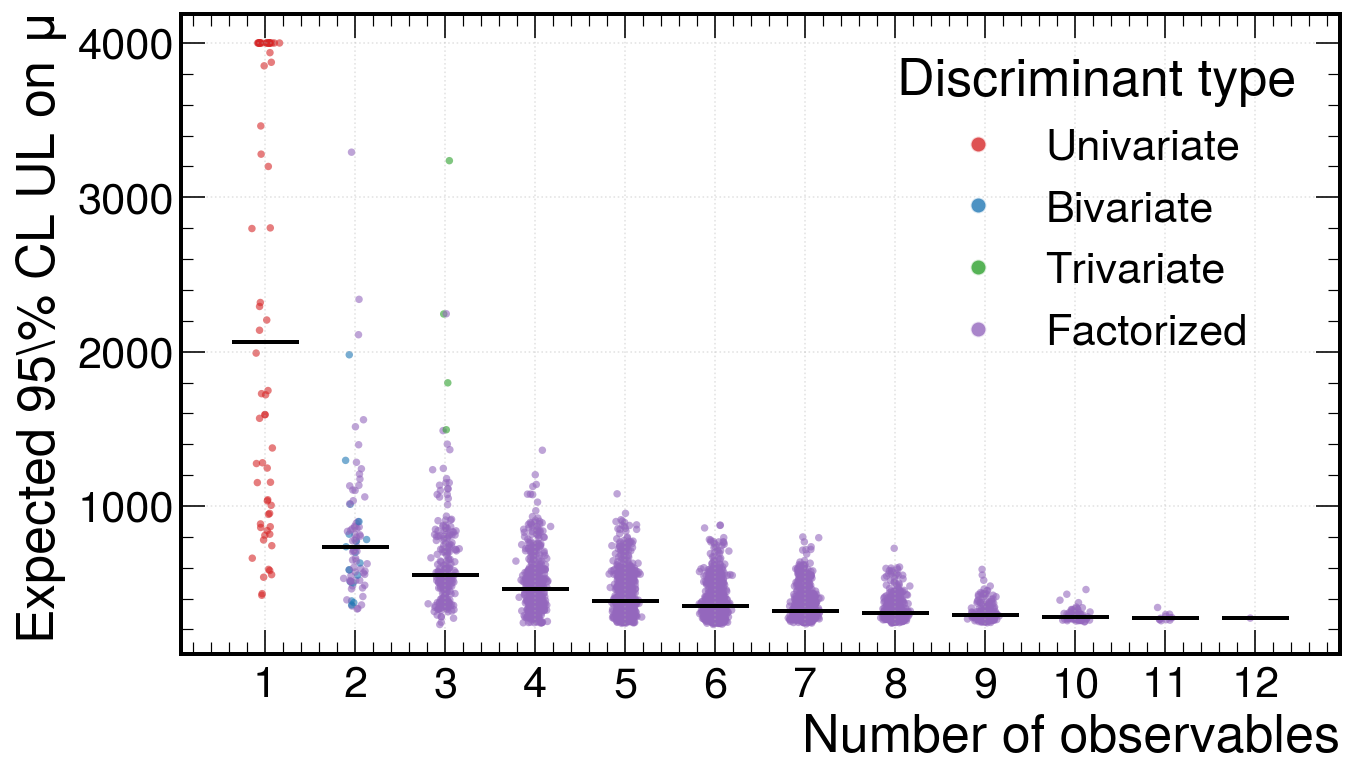

In [9]:
def plot_global_scatter(df: pd.DataFrame, output_dir: Path, add_marginals=False):
    # Ensure n_variables is set for all rows
    map_k = {"from_1D":1, "from_2D":2, "from_3D":3}
    df2 = df.copy()
    if "n_variables" not in df2.columns or df2["n_variables"].isna().any():
        df2["n_variables"] = df2.apply(
            lambda r: map_k.get(r["llr_type"], r.get("n_variables", np.nan)), axis=1
        )
    # Small jitter
    rng = np.random.default_rng(123)
    jitter = rng.normal(0, 0.06, size=len(df2))
    x = df2["n_variables"].astype(int).values + jitter
    y = df2["mu_value"].values

    # Colors by type
    color_map = {
        "from_1D":"tab:red", "from_2D":"tab:blue",
        "from_3D":"tab:green", "from_multivar":"tab:purple"
    }
    colors = df2["llr_type"].map(color_map).values

    fig, ax = plt.subplots(figsize=(10,6))
    ax.scatter(x, y, s=14, c=colors, alpha=0.6, linewidths=0)

    # Per-k medians as horizontal ticks
    med = df2.groupby("n_variables")["mu_value"].median()
    for k, m in med.items():
        ax.plot([k-0.35, k+0.35], [m, m], color="k", lw=2)

    # Pretty x ticks
    ks = sorted(df2["n_variables"].dropna().unique().astype(int))
    ax.set_xticks(ks)
    ax.set_xlabel("Number of observables")
    ax.set_ylabel(r"Expected 95\% CL UL on $\mu$")
    ax.grid(True, alpha=0.35)
    # Legend
    handles = [plt.Line2D([0],[0], marker='o', color='w', label=lab,
                          markerfacecolor=col, markersize=8, alpha=0.8)
               for lab, col in [("Univariate","tab:red"),("Bivariate","tab:blue"),
                                ("Trivariate","tab:green"),("Factorized","tab:purple")]]
    ax.legend(handles=handles, frameon=False, title="Discriminant type")

    out = output_dir / "llr_global_scatter.pdf"
    fig.tight_layout(); fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"Saved {out}")

plot_global_scatter(df, projectdir)

Saved /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/llr_greedy_chain.pdf


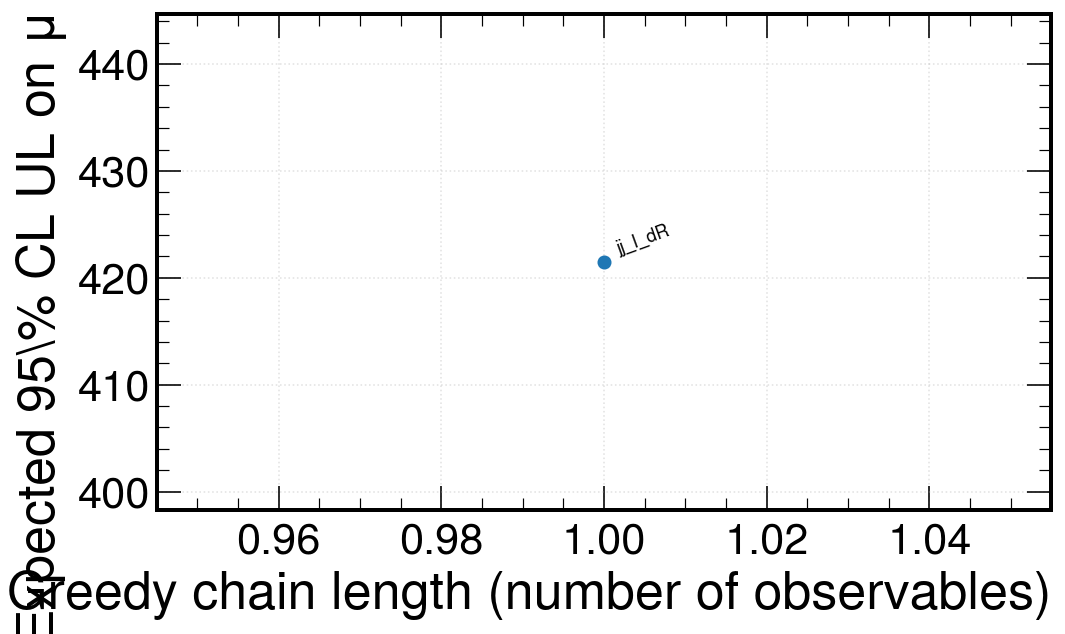

In [10]:
import re

def _vars_from_name(llr_name: str):
    base = llr_name.replace("_llr","")
    parts = [p for p in base.split("_x_") if p]
    return parts

def plot_variable_usage_heatmap(df: pd.DataFrame, output_dir: Path, topN=50, vmax=None):
    hep.style.use("CMS")

    mdf = df[df["llr_type"]=="from_multivar"].copy()
    mdf = mdf.sort_values(["mu_value","llr_name"]).head(topN)

    # Count variables
    from collections import Counter
    counter = Counter()
    for n in mdf["llr_name"]:
        counter.update(_vars_from_name(n))

    vars_sorted = [v for v,_ in counter.most_common()]
    counts = np.array([counter[v] for v in vars_sorted])[None,:]  # shape (1, V)

    fig, ax = plt.subplots(figsize=(0.45*len(vars_sorted)+2, 2.6))
    im = ax.imshow(counts, aspect="auto", cmap="viridis", vmax=vmax)

    ax.set_yticks([0]); ax.set_yticklabels([f"Top {topN} factorized LLRs"])
    ax.set_xticks(range(len(vars_sorted))); ax.set_xticklabels(vars_sorted, rotation=60, ha="right")

    cbar = fig.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label("Occurrences")

    out = output_dir / f"llr_variable_usage_top{topN}.pdf"
    fig.tight_layout(); fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"Saved {out}")

def plot_greedy_chain(df: pd.DataFrame, output_dir: Path, max_k=10):
    hep.style.use("CMS")

    # Best univariate start
    uni = df[df["llr_type"]=="from_1D"].sort_values(["mu_value","llr_name"]).head(1)
    if uni.empty:
        print("No univariate discriminant found."); return

    chain_sets = [set(_vars_from_name(uni.iloc[0]["llr_name"]))]
    chain_names = [uni.iloc[0]["llr_name"]]
    chain_mus   = [uni.iloc[0]["mu_value"]]

    # Prepare multivar rows with parsed sets
    mdf = df[df["llr_type"]=="from_multivar"].copy()
    mdf["var_set"] = mdf["llr_name"].apply(lambda s: frozenset(_vars_from_name(s)))

    for k in range(2, max_k+1):
        prev = chain_sets[-1]
        # Candidates that are strict supersets with +1 element
        cand = mdf[mdf["var_set"].apply(lambda s: len(s)==len(prev)+1 and prev.issubset(s))]
        if cand.empty: break
        best = cand.sort_values(["mu_value","llr_name"]).iloc[0]
        chain_sets.append(set(best["var_set"]))
        chain_names.append(best["llr_name"])
        chain_mus.append(best["mu_value"])

    ks = list(range(1, len(chain_mus)+1))
    fig, ax = plt.subplots(figsize=(8,5))
    ax.plot(ks, chain_mus, marker="o", lw=2)
    for k, name, mu in zip(ks, chain_names, chain_mus):
        ax.annotate(name.replace("_llr",""), (k, mu), xytext=(5,4),
                    textcoords="offset points", fontsize=9, rotation=20)

    ax.set_xlabel("Greedy chain length (number of observables)")
    ax.set_ylabel(r"Expected 95\% CL UL on $\mu$")
    ax.grid(True, alpha=0.35)

    out = output_dir / "llr_greedy_chain.pdf"
    fig.tight_layout(); fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"Saved {out}")

plot_greedy_chain(df, projectdir, max_k=10)

Hierarchical 1D plot saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/hierarchical_1D_llrs.pdf


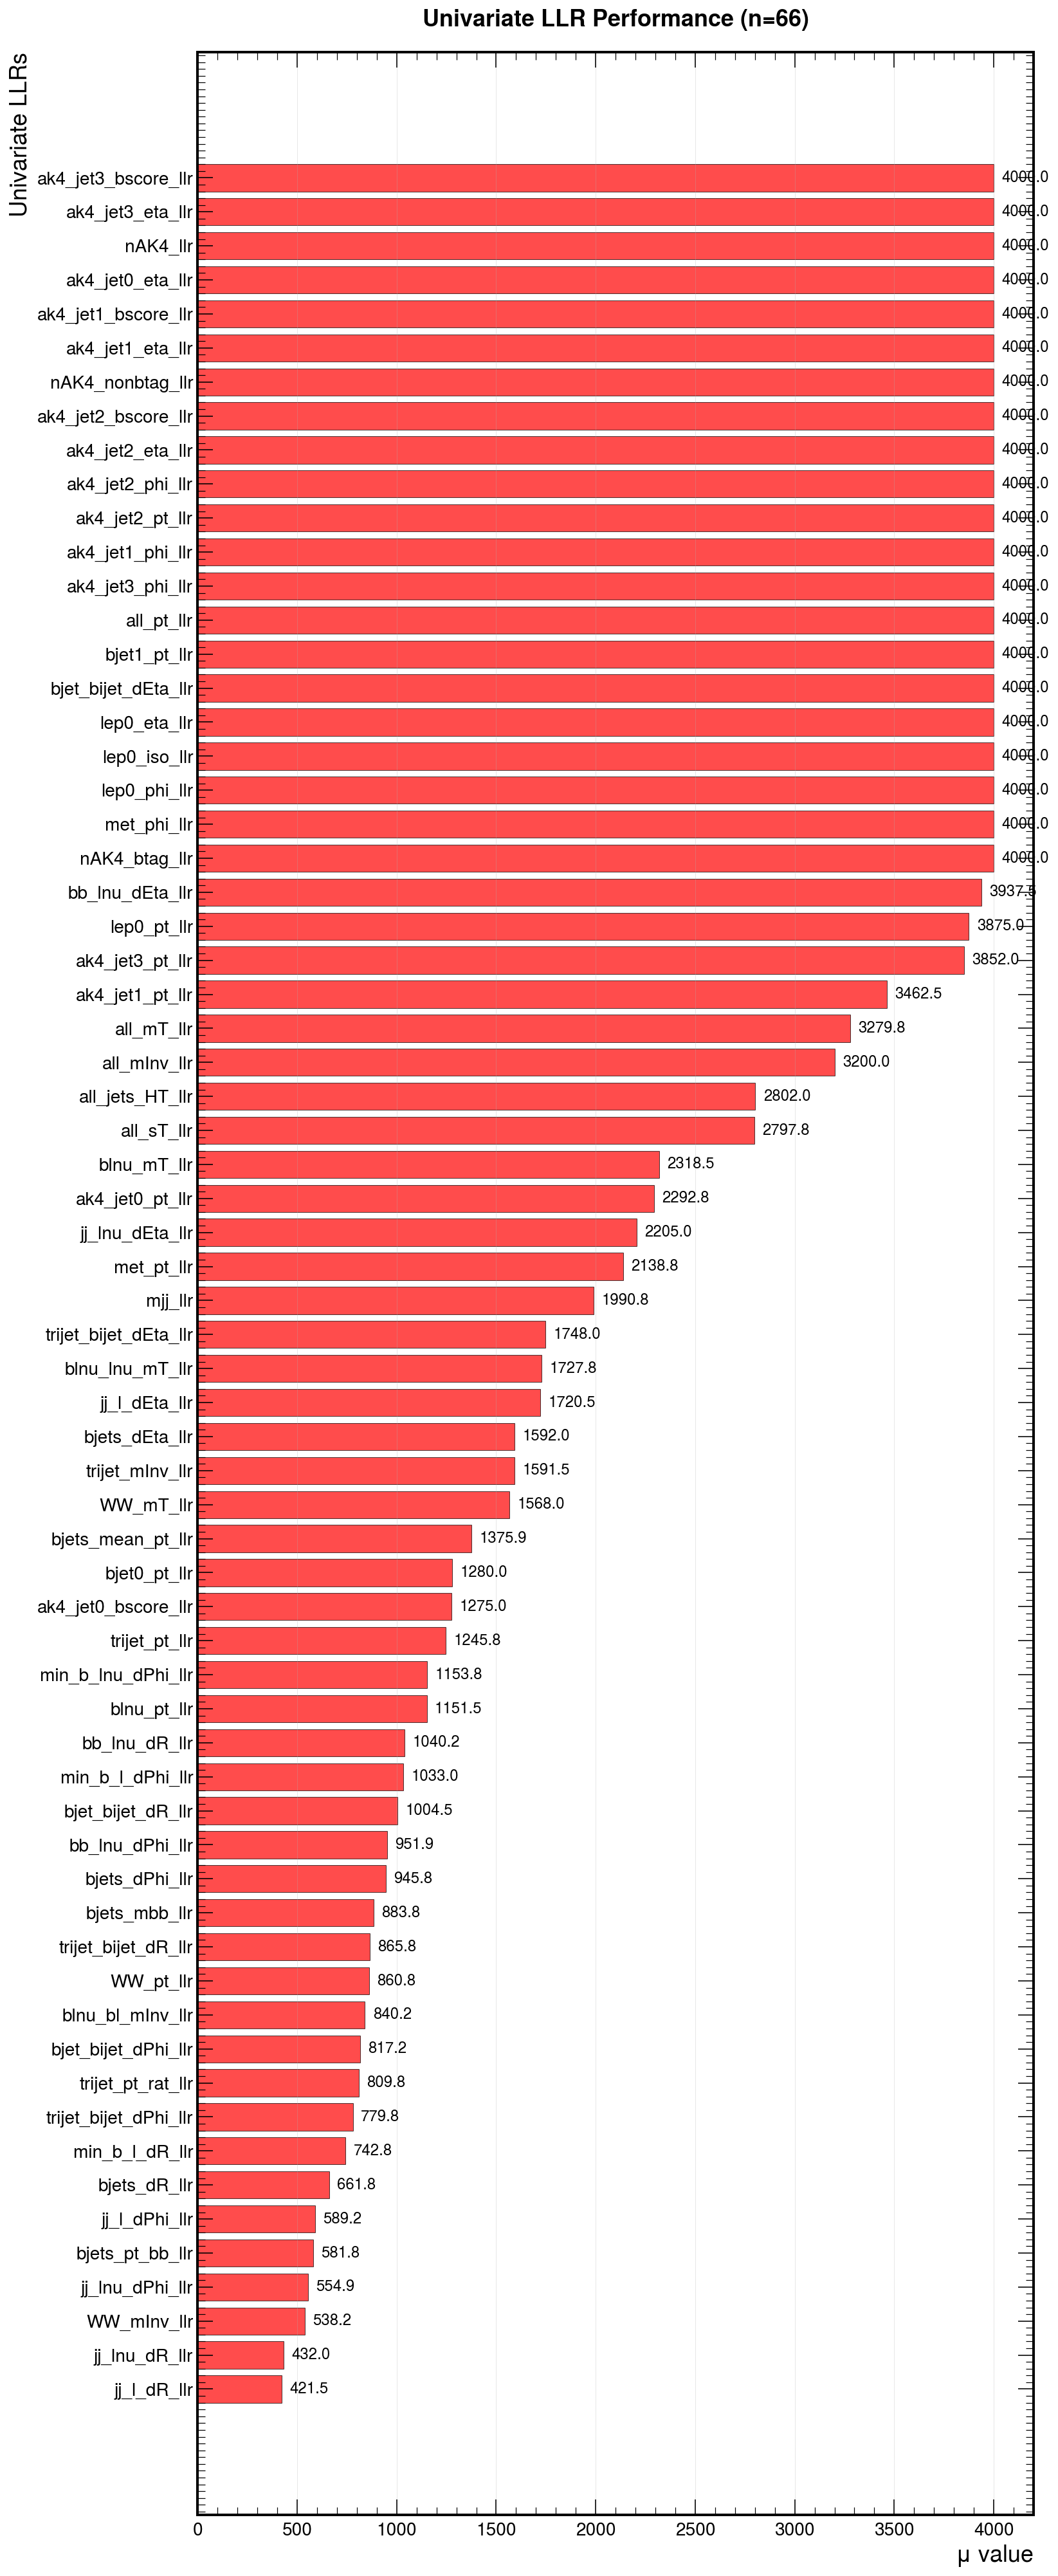

In [18]:
def create_hierarchical_1D_plot(df: pd.DataFrame, output_dir):
    """Create hierarchical plot showing individual 1D LLRs with names."""
    import matplotlib.pyplot as plt
    import numpy as np
    
    hep.style.use("CMS")
    
    label_fontsize = 18
    tick_fontsize = 14
    
    # Filter for only 1D LLRs
    subset_1d = df[df['llr_type'] == 'from_1D'].copy()
    
    if subset_1d.empty:
        print("No 1D LLRs found in dataset")
        return
    
    # Sort by mu_value (best to worst)
    subset_1d = subset_1d.sort_values('mu_value')
    
    fig, ax = plt.subplots(figsize=(12, len(subset_1d) * 0.4 + 2))
    
    # Create horizontal bar plot (easier to read LLR names)
    y_positions = range(len(subset_1d))
    bars = ax.barh(y_positions, subset_1d['mu_value'], 
                   color='red', alpha=0.7, edgecolor='black', linewidth=0.5)
    
    # Clean up LLR names (remove '_llr' suffix for cleaner display)
    # clean_names = [name.replace('_llr', '').replace('_', ' ') for name in subset_1d['llr_name']]
    names = [name for name in subset_1d['llr_name']]
    # Set y-axis labels to LLR names
    ax.set_yticks(y_positions)
    # ax.set_yticklabels(clean_names, fontsize=tick_fontsize)
    ax.set_yticklabels(names, fontsize=tick_fontsize)
    
    # Styling
    ax.set_xlabel('μ value', fontsize=label_fontsize)
    ax.set_ylabel('Univariate LLRs', fontsize=label_fontsize)
    ax.tick_params(axis='x', labelsize=tick_fontsize)
    ax.grid(True, alpha=0.3, axis='x', linestyle='-', linewidth=0.5)
    ax.set_title(f'Univariate LLR Performance (n={len(subset_1d)})', 
                 fontsize=label_fontsize, fontweight='bold', pad=20)
    
    # Add value labels on bars
    for i, (bar, value) in enumerate(zip(bars, subset_1d['mu_value'])):
        ax.text(value + max(subset_1d['mu_value']) * 0.01, i, f'{value:.1f}', 
                va='center', fontsize=tick_fontsize-2)
    
    plt.tight_layout()
    
    save_path = output_dir / "hierarchical_1D_llrs.pdf"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Hierarchical 1D plot saved to {save_path}")
    
    plt.show()

# Usage
create_hierarchical_1D_plot(df, projectdir)

In [19]:
# Create a clean ranking DataFrame
from_1d_ranking = df[df['llr_type'] == 'from_1D'][['llr_name', 'mu_value']].copy()
from_1d_ranking = from_1d_ranking.sort_values('mu_value').reset_index(drop=True)
from_1d_ranking['rank'] = range(1, len(from_1d_ranking) + 1)
from_1d_ranking = from_1d_ranking[['rank', 'llr_name', 'mu_value']]

# Display
print(from_1d_ranking.to_string(index=False))

 rank              llr_name  mu_value
    1           jj_l_dR_llr  421.5000
    2         jj_lnu_dR_llr  432.0000
    3           WW_mInv_llr  538.2500
    4       jj_lnu_dPhi_llr  554.9375
    5       bjets_pt_bb_llr  581.7500
    6         jj_l_dPhi_llr  589.2500
    7          bjets_dR_llr  661.7500
    8        min_b_l_dR_llr  742.7500
    9 trijet_bijet_dPhi_llr  779.7500
   10     trijet_pt_rat_llr  809.7500
   11   bjet_bijet_dPhi_llr  817.2500
   12      blnu_bl_mInv_llr  840.2500
   13             WW_pt_llr  860.7500
   14   trijet_bijet_dR_llr  865.7500
   15         bjets_mbb_llr  883.7500
   16        bjets_dPhi_llr  945.7500
   17       bb_lnu_dPhi_llr  951.8750
   18     bjet_bijet_dR_llr 1004.5000
   19      min_b_l_dPhi_llr 1033.0000
   20         bb_lnu_dR_llr 1040.2500
   21           blnu_pt_llr 1151.5000
   22    min_b_lnu_dPhi_llr 1153.7500
   23         trijet_pt_llr 1245.7500
   24   ak4_jet0_bscore_llr 1275.0000
   25          bjet0_pt_llr 1280.0000
   26     bj

In [26]:
top_10_1d_llrs = from_1d_ranking['llr_name'][:10].to_list()
top_10_1d_llrs


['jj_l_dR_llr',
 'jj_lnu_dR_llr',
 'WW_mInv_llr',
 'jj_lnu_dPhi_llr',
 'bjets_pt_bb_llr',
 'jj_l_dPhi_llr',
 'bjets_dR_llr',
 'min_b_l_dR_llr',
 'trijet_bijet_dPhi_llr',
 'trijet_pt_rat_llr']

In [22]:
reserved = [
    'lep0_pt',                                      
    'bjets_mbb', 'bjets_dR', 'bjets_pt_bb', 'bjet0_pt', 'bjet1_pt',         # bjet-vars
    'blnu_mT', 'blnu_pt',                                                   # leptonic-top 
    'trijet_mInv', 'trijet_pt', 'trijet_pt_rat', 'trijet_bijet_dR'          # hadronic-top 
]
# Create the full LLR names by adding '_llr' suffix
reserved_llr_names = [var + '_llr' for var in reserved]

# Filter the ranking for only the reserved LLRs
reserved_ranking = from_1d_ranking[from_1d_ranking['llr_name'].isin(reserved_llr_names)].copy()

# Display the results
print(f"Ranking of Reserved LLRs ({len(reserved_ranking)} out of {len(reserved)} found):")
print("-" * 60)
for _, row in reserved_ranking.iterrows():
    print(f"{row['rank']:2d}. {row['llr_name']:<25} μ = {row['mu_value']:8.3f}")

# Check if any reserved LLRs are missing
missing_llrs = set(reserved_llr_names) - set(reserved_ranking['llr_name'])
if missing_llrs:
    print(f"\nMissing from 1D rankings: {missing_llrs}")

Ranking of Reserved LLRs (12 out of 12 found):
------------------------------------------------------------
 5. bjets_pt_bb_llr           μ =  581.750
 7. bjets_dR_llr              μ =  661.750
10. trijet_pt_rat_llr         μ =  809.750
14. trijet_bijet_dR_llr       μ =  865.750
15. bjets_mbb_llr             μ =  883.750
21. blnu_pt_llr               μ = 1151.500
23. trijet_pt_llr             μ = 1245.750
25. bjet0_pt_llr              μ = 1280.000
28. trijet_mInv_llr           μ = 1591.500
37. blnu_mT_llr               μ = 2318.500
44. lep0_pt_llr               μ = 3875.000
52. bjet1_pt_llr              μ = 4000.000
